In [1]:
import os
import json
import math
from tqdm import tqdm
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
from diffusers import StableDiffusionXLPipeline
import matplotlib.pyplot as plt
import random
import sys
sys.path.append("/teamspace/studios/this_studio/src")
from dataset.vitonhd import VitonHDDataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch

# Data Loading

In [2]:
data_path = "/teamspace/studios/this_studio/data"
os.listdir(data_path)

['train_pairs.txt',
 'vitonhd.json',
 'test',
 'test_pairs.txt',
 'warped_cloths',
 'train',
 'warped_cloths_unpaired']

In [3]:
train_dataset = VitonHDDataset(
    dataroot_path=data_path,
    phase="train",
    captions_file="train.jsonl"
)

val_dataset = VitonHDDataset(
    dataroot_path=data_path,
    phase="train",
    captions_file="val.jsonl"
)

test_dataset = VitonHDDataset(
    dataroot_path=data_path,
    phase="test",
    captions_file="test.jsonl"
)

print(f"The size of the training set = {len(train_dataset)}")
print(f"The size of the validation set = {len(val_dataset)}")
print(f"The size of the testing set = {len(test_dataset)}")

The size of the training set = 10482
The size of the validation set = 1165
The size of the testing set = 2032


In [4]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=True
)

In [5]:
from torch.utils.data import Subset, DataLoader

fixed_indices = [129, 337, 237, 756, 532, 103, 1153, 345]
fixed_subset = Subset(val_dataset, fixed_indices)

fixed_loader = DataLoader(
    fixed_subset,
    batch_size=len(fixed_indices),
    shuffle=False
)

fixed_batch = next(iter(fixed_loader))

In [6]:
fixed_images = fixed_batch["cloth"].to(device)
fixed_captions = fixed_batch["cloth_captions"]

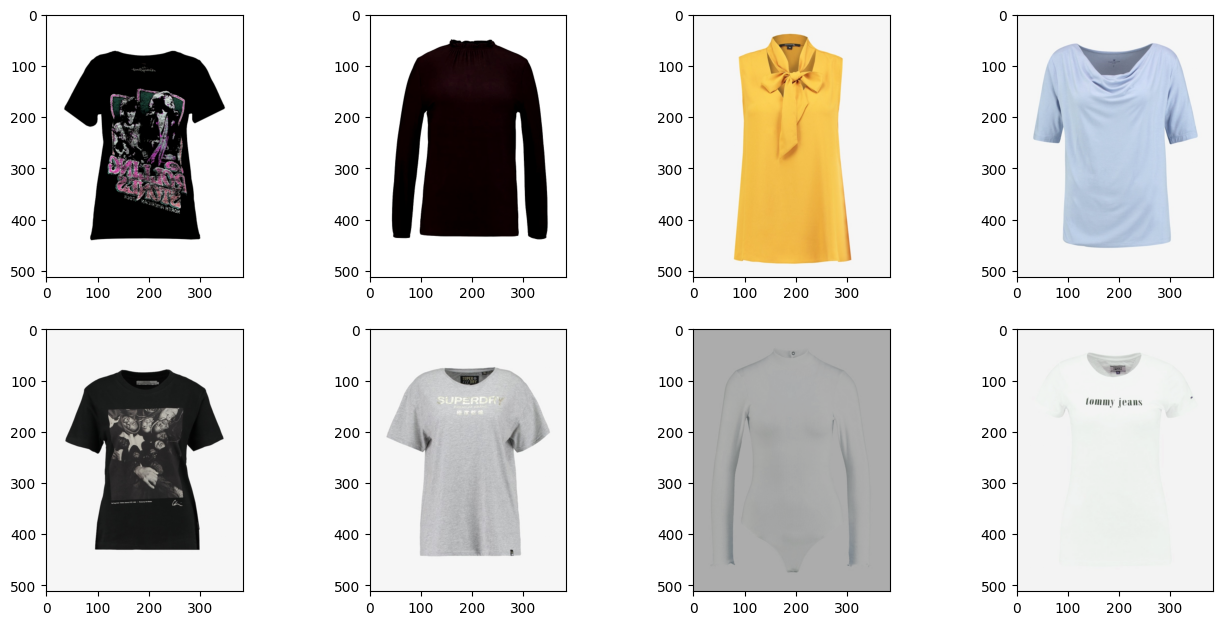

In [7]:
plt.figure(figsize=(16, 32))

for i in range(fixed_batch["cloth"].shape[0]):
    plt.subplot(8,4,i+1)
    img = (fixed_batch["cloth"][i] * 0.5) + 0.5
    plt.imshow(img.permute(1,2,0))

plt.show()

In [8]:
for i in range(fixed_batch["cloth"].shape[0]):
    print(f"({i+1}): {fixed_batch["cloth_captions"][i]}")

(1): T-shirt, black, cotton, short sleeves, crew neck, fitted, solid, graphic print of The Rolling Stones, "The Rolling Stones" logo, "Rolling Stones North American Tour" text, casual style
(2): long-sleeved top, navy blue, smooth, long sleeves, high neck with ruffle detail, fitted, minimalist fashion style
(3): Blouse, Yellow, Silk-like, sleeveless, Stand-up collar with bow tie, Tunic, Solid, Comma brand logo on collar
(4): T-shirt, light blue, 3/4 sleeves, cowl neck, loose, solid, Tom Tailor, Text on the
(5): T-shirt, black, cotton, short sleeves, crew neck, loose fit, solid, graphic print of Wu-Tang Clan members, signature logo "Chi, " text "Wu Tang Clan Staten Island, NYC 1993 Photo by Chi Modu, " no closures, casual style
(6): T-shirt, light gray marled, cotton, short sleeves, crew neck, loose fit, solid, "SUPERDRY PREMIUM BRAND" in gold and black, "極度乾燥" in Chinese characters below the brand name, casual style
(7): bodysuit, white, ribbed knit, long sleeves, high neck, fitted, bu

In [9]:
fixed_batch["cloth"].shape

torch.Size([8, 3, 512, 384])

# Stable Diffusion

In [10]:
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer, CLIPVisionModelWithProjection, CLIPTextModelWithProjection
model_path = "stabilityai/stable-diffusion-xl-base-1.0"
#model_path = "runwayml/stable-diffusion-v1-5"

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


## VAE

### Why to use VAE?
- The VAE used to enable the stable diffusion model work on the latent space rather that the pixel space to save memory and speed training and that's why itis called a latent diffusion model.
- It will be used during training to encode images and pass the latent representations of the images to the diffusion model that will work on these latent representations.
- After the diffusion model finishes the denoising steps and generates the pure latent representations, it will be passed to the decoder of the VAE to reconstrct the image from these latents.

In [11]:
vae = AutoencoderKL.from_pretrained(
    model_path,
    subfolder="vae"
)
vae = vae.to(device)

In [12]:
# This function uses the encoder of the VAE and it takes an image as an input then return its latent representations
def encode_img(img):
    with torch.no_grad():
        latents = vae.encode(img) # Get the latent representations of the image
        latents = latents.latent_dist.sample() # Take a sample from the distribution of the latent space of the VAE
        latents = latents * vae.config.scaling_factor # scale the latents 
    return latents

In [13]:
# This function uses the VAE decoder, it takes as input a latent representations of an image then it reconstruct this image from its latent representation and return the image
def decode_latents(latents):
    with torch.no_grad():
        recon_img = vae.decode(latents / vae.config.scaling_factor).sample # return the latent representations to its original scale then reconstruct it
    return recon_img

### Testing the reconstruction ability of the VAE
- Load a sample from the dataset (Edge and Shoe)
- I will encode these 2 images using the encode_img function
- Then I will use the decode_latents function to reconstruct the original images
- Then plot the results (Original images and Reconstructed images)

In [14]:
img = fixed_batch["cloth"][0]
img = img.unsqueeze(0) # preparing the image for the expected dimensions in the VAE
img = img.to(device)

In [15]:
# Encode cloth image
latents = encode_img(img)
print(f"Latent Representations Shape: {latents.shape}")

Latent Representations Shape: torch.Size([1, 4, 64, 48])


In [16]:
# Reconstruct cloth image
recon_img = decode_latents(latents)
print(f"Reconstructed Cloth Image Shape: {recon_img.shape}")

Reconstructed Cloth Image Shape: torch.Size([1, 3, 512, 384])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


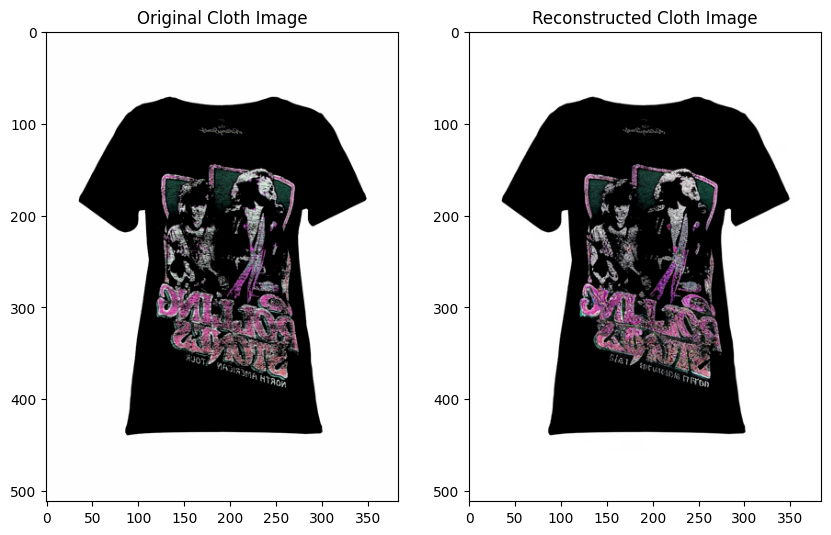

In [17]:
plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plt.title("Original Cloth Image")
img = img.squeeze(0) # prepare the image for the expected dimensions in matplotlib (removing the channel that represent the size of batch)
img = img * 0.5 + 0.5 
plt.imshow(img.permute(1,2,0).cpu())

plt.subplot(1,2,2)
plt.title("Reconstructed Cloth Image")
recon_img = recon_img.squeeze(0)
recon_img = recon_img * 0.5 + 0.5
plt.imshow(recon_img.permute(1,2,0).cpu())

plt.show()

## UNet

### Why Loading UNet?
- UNet is the main component in the stable diffusion architecture
- Itis the one that is trained to learn how to move to the real data distribution from a random distribution following the input conditions
- The training objective is to minimize the MSE error loss value between the predicted noise and the real noise
- Then after training ends, the model will be able to take a noisy image and predict the noise value that is added in the image and using the noise scheduler we can take a denoising step in the direction of the real images distribution

In [18]:
# UNet loading
unet = UNet2DConditionModel.from_pretrained(
    model_path,
    subfolder="unet"
)
unet = unet.to(device)

In [19]:
conv_in = unet.conv_in
print(f"The current input layer of the UNet is: {conv_in}")

The current input layer of the UNet is: Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


## Noise Scheduler

### Why using Noise Scheduler?
- It will be used to add noise to the latent representations of the images in the forward diffusion process
- And performing denoising steps with the predicted noise values from the unet in the backward diffusion process

In [20]:
noise_scheduler = DDPMScheduler.from_pretrained(
    model_path,
    subfolder="scheduler"
)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


## Tokenizer

### Why using CLIP Tokenizer?
- Since, the stable diffusion model is a text-to-image model, this means it expects input text embeddings to the architecture
- The Tokenizer will be used to encode the captions of the clothing images

In [21]:
tokenizer = CLIPTokenizer.from_pretrained(
    model_path,
    subfolder="tokenizer"
)

In [22]:
tokenizer_2 = CLIPTokenizer.from_pretrained(
    model_path,
    subfolder="tokenizer_2"
)

## Text Encoder

After getting the tokens from the CLIP tokenizers, the text encoder will be used to get the embeddings of these tokens and pass them to the diffusion model

In [23]:
text_encoder = CLIPTextModel.from_pretrained(
    model_path,
    subfolder="text_encoder"
)
text_encoder = text_encoder.to(dtype=unet.dtype, device=device)

In [24]:
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
    model_path,
    subfolder="text_encoder_2"
)
text_encoder_2 = text_encoder_2.to(dtype=unet.dtype, device=device)

In [25]:
def encode_prompt(captions):

    text_inputs = tokenizer(
        captions,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    )

    text_inputs_2 = tokenizer_2(
        captions,
        padding="max_length",
        truncation=True,
        max_length=tokenizer_2.model_max_length,
        return_tensors="pt"
    )

    input_ids = text_inputs.input_ids.to(device)
    input_ids_2 = text_inputs_2.input_ids.to(device)

    with torch.no_grad():

        enc1 = text_encoder(
            input_ids,
            output_hidden_states=True
        )

        enc2 = text_encoder_2(
            input_ids_2,
            output_hidden_states=True
        )

    prompt_embeds = torch.cat(
        [
            enc1.hidden_states[-2],
            enc2.hidden_states[-2]
        ],
        dim=-1
    )

    pooled_prompt_embeds = enc2.text_embeds

    return prompt_embeds, pooled_prompt_embeds

In [26]:
captions = fixed_batch["cloth_captions"][:2]

prompt_embeds, pooled_prompt_embeds = encode_prompt(captions)

print(prompt_embeds.shape)
print(pooled_prompt_embeds.shape)

torch.Size([2, 77, 2048])
torch.Size([2, 1280])


## Testing The Original SDXL

In [27]:
# Prepare the UNet for training
unet = unet.to(device)
unet.train()

# Freeze the VAE and the Text Encoder
# VAE
vae.requires_grad_(False)
vae.eval()

# Text Encoder 1
text_encoder.requires_grad_(False)
text_encoder.eval()

# Text Encoder 2
text_encoder_2.requires_grad_(False)
text_encoder_2.eval()

print("Ready")

Ready


In [28]:
@torch.no_grad()
def generate_images(
    unet,
    test_batch,
    model_path,
    device,
    vae,
    tokenizer,
    tokenizer_2,
    text_encoder,
    text_encoder_2,
    noise_scheduler,
    num_inference_steps=30,
    guidance_scale=7.5,
    seed=42,
):

    unet.eval()

    pipe = StableDiffusionXLPipeline.from_pretrained(
        model_path,
        unet=unet,
        vae=vae,
        tokenizer=tokenizer,
        tokenizer_2=tokenizer_2,
        text_encoder=text_encoder,
        text_encoder_2=text_encoder_2,
        scheduler=noise_scheduler,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to(device)

    captions = test_batch["cloth_captions"]

    generator = torch.Generator(
        device=device
    ).manual_seed(seed)

    with torch.inference_mode():

        generated_images = pipe(
            prompt=captions,
            negative_prompt=[
                "low quality, blurry, watermark, deformed"
            ] * len(captions),
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            height=512,
            width=384,
            generator=generator,
        ).images

    del pipe
    torch.cuda.empty_cache()

    return generated_images

In [29]:
generated_images = generate_images(
    unet=unet,
    test_batch=fixed_batch,
    model_path=model_path,
    device=device,
    vae=vae,
    tokenizer=tokenizer,
    tokenizer_2=tokenizer_2,
    text_encoder=text_encoder,
    text_encoder_2=text_encoder_2,
    noise_scheduler=noise_scheduler,
)

Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

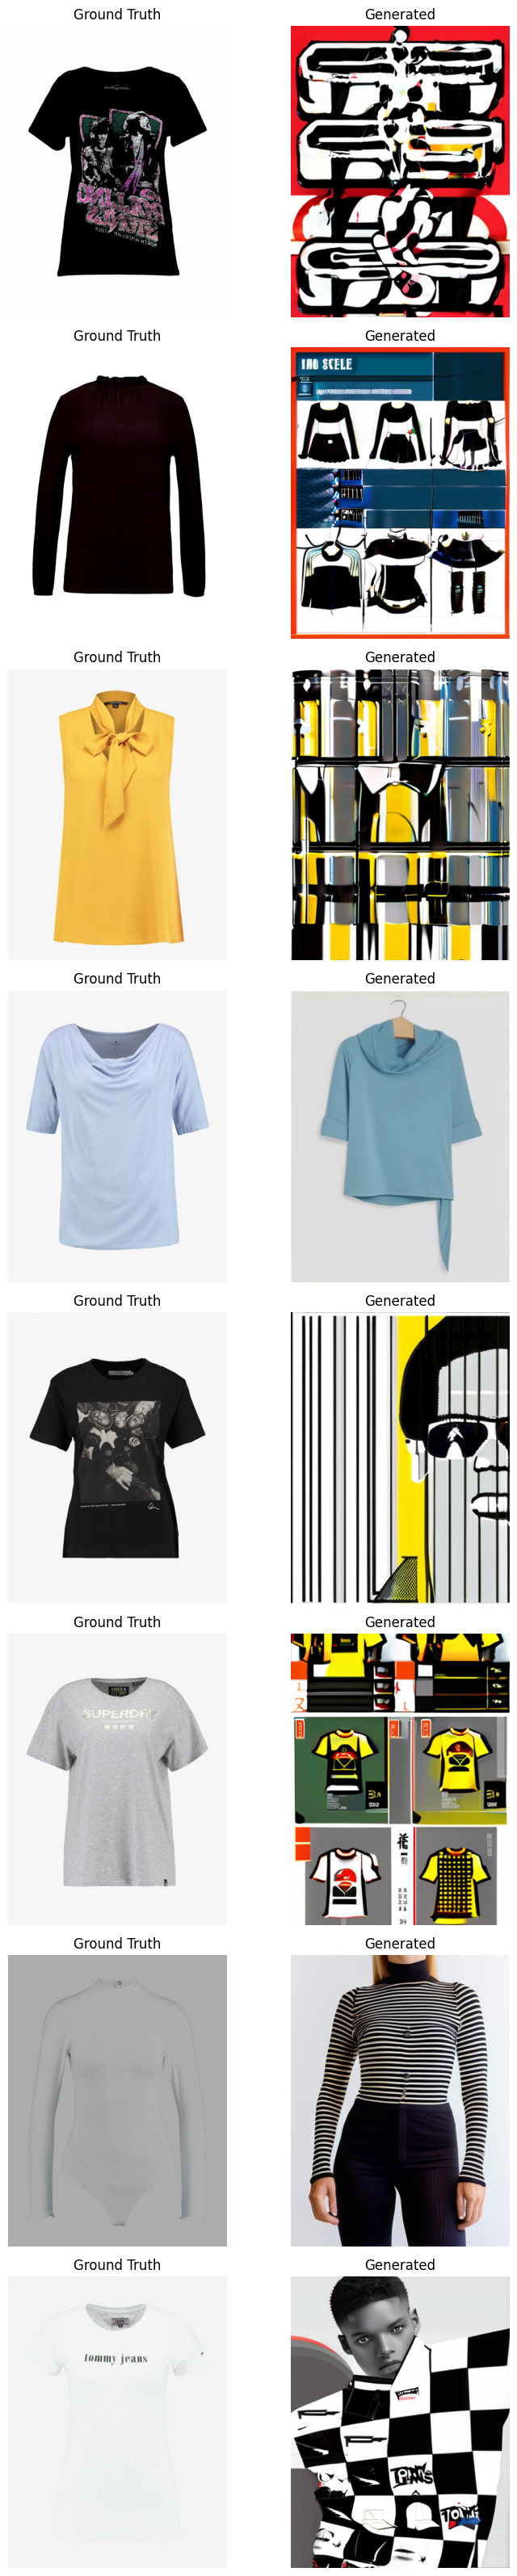

In [30]:
gt_images = fixed_batch["cloth"].cpu()

batch_size = len(generated_images)

fig, axes = plt.subplots(
    batch_size,
    2,
    figsize=(8, 4 * batch_size)
)

# Handle batch_size = 1
if batch_size == 1:
    axes = axes.reshape(1, 2)

for i in range(batch_size):

    # Ground Truth
    gt = gt_images[i].permute(1, 2, 0)
    gt = ((gt + 1) / 2).clamp(0, 1)

    # Generated (PIL image)
    gen = generated_images[i]

    axes[i, 0].imshow(gt)
    axes[i, 0].set_title("Ground Truth")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gen)
    axes[i, 1].set_title("Generated")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Training

In [31]:
# Prepare the UNet for training
unet = unet.to(device)
unet.train()

# Freeze the VAE and the Text Encoder
# VAE
vae.requires_grad_(False)
vae.eval()

# Text Encoder 1
text_encoder.requires_grad_(False)
text_encoder.eval()

# Text Encoder 2
text_encoder_2.requires_grad_(False)
text_encoder_2.eval()

print("Ready")

Ready


In [32]:
# Using the AdamW optimizer and the MSE loss function
optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=1e-5,
    betas=(0.9, 0.999),
    weight_decay=1e-2
)
criterion = nn.MSELoss()

In [33]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(
        f"Trainable: {trainable:,} / {total:,}"
    )

count_params(vae)
count_params(text_encoder)
count_params(text_encoder_2)
count_params(unet)

Trainable: 0 / 83,653,863
Trainable: 0 / 123,060,480
Trainable: 0 / 694,659,840
Trainable: 2,567,463,684 / 2,567,463,684


In [34]:
def compute_time_ids(batch_size):
    original_size = (512, 384)
    crop_coords = (0, 0)
    target_size = (512, 384)

    add_time_ids = list(original_size + crop_coords + target_size)

    add_time_ids = torch.tensor(
        [add_time_ids],
        dtype=torch.float32,
        device=device
    )

    add_time_ids = add_time_ids.repeat(batch_size, 1)
    return add_time_ids

In [35]:
@torch.no_grad()
def evaluate(
    unet,
    val_loader,
):
    unet.eval()

    total_loss = 0

    for batch in val_loader:

        cloth_images = batch["cloth"].to(device)
        cloth_captions = batch["cloth_captions"]

        batch_size = cloth_images.shape[0]

        cloth_latents = encode_img(cloth_images)

        noise = torch.randn_like(cloth_latents)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=device
        ).long()

        noisy_latents = noise_scheduler.add_noise(
            cloth_latents,
            noise,
            timesteps
        )

        prompt_embeds, pooled_prompt_embeds = encode_prompt(
            cloth_captions
        )

        add_time_ids = compute_time_ids(batch_size)

        noise_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=prompt_embeds,
            added_cond_kwargs={
                "text_embeds": pooled_prompt_embeds,
                "time_ids": add_time_ids,
            },
        ).sample

        loss = criterion(
            noise_pred,
            noise
        )

        total_loss += loss.item()

    unet.train()

    return total_loss / len(val_loader)

In [36]:
def denormalize(img):
    img = img.detach().cpu()
    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)
    return img


def save_monitoring_grid(
    gt_images,
    generated_images,
    epoch,
    step,
    save_dir="monitoring",
):

    os.makedirs(save_dir, exist_ok=True)

    gt_images = denormalize(gt_images)

    batch_size = len(generated_images)

    fig, axes = plt.subplots(
        batch_size,
        2,
        figsize=(8, 4 * batch_size)
    )

    if batch_size == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(batch_size):

        gt = gt_images[i].permute(1, 2, 0).numpy()

        axes[i, 0].imshow(gt)
        axes[i, 0].set_title("GT")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(generated_images[i])
        axes[i, 1].set_title("Generated")
        axes[i, 1].axis("off")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            save_dir,
            f"epoch_{epoch+1}_step_{step}.png"
        )
    )

    plt.close()

In [37]:
print(unet.dtype)
print(next(unet.parameters()).dtype)

print(next(text_encoder.parameters()).dtype)
print(next(text_encoder_2.parameters()).dtype)

print(next(vae.parameters()).dtype)

torch.float32
torch.float32
torch.float32
torch.float32
torch.float32


In [38]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
global_step = 0
n_epochs = 10

for epoch in range(n_epochs):
    
    progress_bar = tqdm(train_loader)
    progress_bar.set_description(f"Epoch {epoch+1}")
    epoch_loss = 0
    
    for batch in progress_bar:

        global_step += 1
        
        if global_step % 500 == 0:
            
            generated_images = generate_images(
                unet=unet,
                test_batch=fixed_batch,
                model_path=model_path,
                device=device,
                vae=vae,
                tokenizer=tokenizer,
                tokenizer_2=tokenizer_2,
                text_encoder=text_encoder,
                text_encoder_2=text_encoder_2,
                noise_scheduler=noise_scheduler,
            )
            
            save_monitoring_grid(
                gt_images=fixed_images,
                generated_images=generated_images,
                epoch=epoch,
                step=global_step,
            )
        
            unet.train()
            
        # Load data inputs
        cloth_images = batch["cloth"].to(device)
        cloth_captions = batch["cloth_captions"]
        batch_size = cloth_images.shape[0]

        # Convert the shoe image to the latent space
        with torch.no_grad():
            cloth_latents = encode_img(cloth_images)

        # Forward pass
        noise = torch.randn_like(cloth_latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=device
        ).long()
        noisy_latents = noise_scheduler.add_noise(
            cloth_latents,
            noise,
            timesteps
        )
        
        prompt_embeds, pooled_prompt_embeds = encode_prompt(
            cloth_captions
        )

        add_time_ids = compute_time_ids(batch_size)

        # Model Prediction
        noise_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=prompt_embeds,
            added_cond_kwargs={
                "text_embeds": pooled_prompt_embeds,
                "time_ids": add_time_ids,
            },
        ).sample

        # Compute Loss
        loss = criterion(noise_pred, noise)
        epoch_loss += loss.item()

        # Backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    val_loss = evaluate(unet, val_loader)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")
    torch.save({"train_losses": train_losses, "val_losses": val_losses}, "loss_history.pt")

    if val_loss < best_val_loss:
        
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "global_step": global_step,
            "val_loss": val_loss,
            "unet_state_dict": unet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }, "best_model.pth")
    
    torch.save({
        "epoch": epoch,
        "global_step": global_step,
        "train_loss": epoch_loss,
        "val_loss": val_loss,
        "best_val_loss": best_val_loss,
        "unet_state_dict": unet.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, "last_model.pth")

Epoch 1:  38%|███▊      | 499/1311 [14:56<24:22,  1.80s/it]Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1:  76%|███████▌  | 999/1311 [30:24<09:18,  1.79s/it]  Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 10:  92%|█████████▏| 1200/1311 [36:59<03:18,  1.79s/it] Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 10: 100%|██████████| 1311/1311 [40:47<00:00,  1.87s/it]


Epoch 10 | Train Loss: 0.0591 | Val Loss: 0.0596


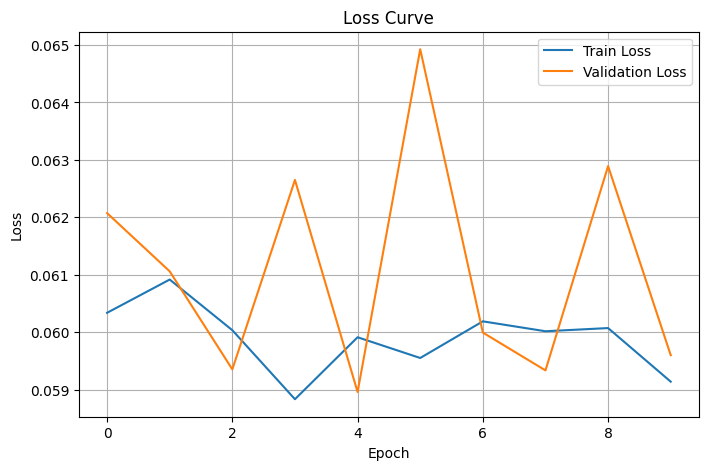

In [38]:
# Plotting Learning Curve
loss = torch.load("loss_history.pt", map_location="cpu")
train_loss = loss["train_losses"]
val_loss = loss["val_losses"]

plt.figure(figsize=(8, 5))
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.show()

## Continue Training for 3 Epochs

In [39]:
checkpoint = torch.load("last_model.pth", map_location=device)

unet.load_state_dict(
    checkpoint["unet_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"] + 1
global_step = checkpoint["global_step"]

best_val_loss = checkpoint["best_val_loss"]

print(
    f"Resuming from epoch {start_epoch}"
)

Resuming from epoch 10


In [41]:
print(
    f"Resuming from epoch={checkpoint['epoch']} "
    f"global_step={global_step} "
    f"best_val_loss={best_val_loss:.6f}"
)

Resuming from epoch=9 global_step=13110 best_val_loss=0.058959


In [40]:
history = torch.load("loss_history.pt")
train_losses = history["train_losses"]
val_losses = history["val_losses"]

In [ ]:
unet.train()
additional_epochs = 3

for epoch in range(start_epoch, start_epoch + additional_epochs):
    
    progress_bar = tqdm(train_loader)
    progress_bar.set_description(f"Epoch {epoch+1}")
    epoch_loss = 0
    
    for batch in progress_bar:

        global_step += 1
        
        if global_step % 500 == 0:
            
            generated_images = generate_images(
                unet=unet,
                test_batch=fixed_batch,
                model_path=model_path,
                device=device,
                vae=vae,
                tokenizer=tokenizer,
                tokenizer_2=tokenizer_2,
                text_encoder=text_encoder,
                text_encoder_2=text_encoder_2,
                noise_scheduler=noise_scheduler,
            )
            
            save_monitoring_grid(
                gt_images=fixed_images,
                generated_images=generated_images,
                epoch=epoch,
                step=global_step,
            )
        
            unet.train()
            
        # Load data inputs
        cloth_images = batch["cloth"].to(device)
        cloth_captions = batch["cloth_captions"]
        batch_size = cloth_images.shape[0]

        # Convert the shoe image to the latent space
        with torch.no_grad():
            cloth_latents = encode_img(cloth_images)

        # Forward pass
        noise = torch.randn_like(cloth_latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=device
        ).long()
        noisy_latents = noise_scheduler.add_noise(
            cloth_latents,
            noise,
            timesteps
        )
        
        prompt_embeds, pooled_prompt_embeds = encode_prompt(
            cloth_captions
        )

        add_time_ids = compute_time_ids(batch_size)

        # Model Prediction
        noise_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=prompt_embeds,
            added_cond_kwargs={
                "text_embeds": pooled_prompt_embeds,
                "time_ids": add_time_ids,
            },
        ).sample

        # Compute Loss
        loss = criterion(noise_pred, noise)
        epoch_loss += loss.item()

        # Backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    val_loss = evaluate(unet, val_loader)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")
    torch.save({"train_losses": train_losses, "val_losses": val_losses}, "loss_history.pt")

    if val_loss < best_val_loss:
        
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "global_step": global_step,
            "val_loss": val_loss,
            "unet_state_dict": unet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }, "best_model.pth")
    
    torch.save({
        "epoch": epoch,
        "global_step": global_step,
        "train_loss": epoch_loss,
        "val_loss": val_loss,
        "best_val_loss": best_val_loss,
        "unet_state_dict": unet.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, "last_model.pth")

Epoch 11:  30%|██▉       | 389/1311 [12:24<29:30,  1.92s/it]Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 11:  68%|██████▊   | 889/1311 [28:53<13:28,  1.92s/it]  Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 12: 100%|██████████| 1311/1311 [43:26<00:00,  1.99s/it]


Epoch 12 | Train Loss: 0.0605 | Val Loss: 0.0590


Epoch 13:   2%|▏         | 28/1311 [00:54<41:05,  1.92s/it]

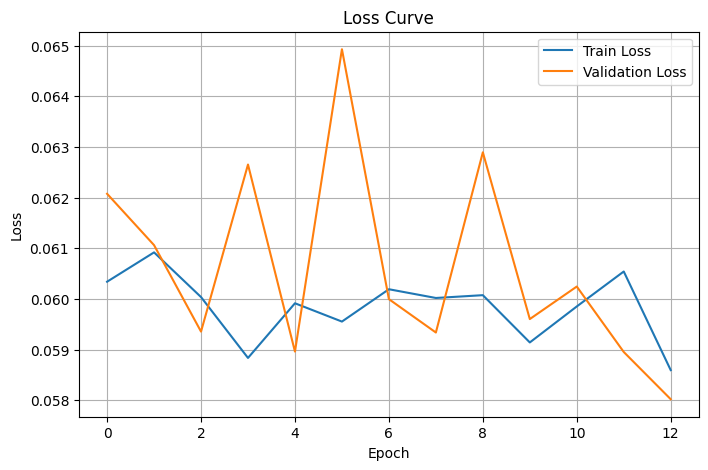

In [38]:
# Plotting Learning Curve
loss = torch.load("loss_history.pt", map_location="cpu")
train_loss = loss["train_losses"]
val_loss = loss["val_losses"]

plt.figure(figsize=(8, 5))
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.show()

## Epoch

In [39]:
checkpoint = torch.load("last_model.pth", map_location=device)

unet.load_state_dict(
    checkpoint["unet_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"] + 1
global_step = checkpoint["global_step"]

best_val_loss = checkpoint["best_val_loss"]

print(
    f"Resuming from epoch {start_epoch}"
)

Resuming from epoch 13


In [40]:
history = torch.load("loss_history.pt")
train_losses = history["train_losses"]
val_losses = history["val_losses"]

In [41]:
unet.train()
additional_epochs = 2

for epoch in range(start_epoch, start_epoch + additional_epochs):
    
    progress_bar = tqdm(train_loader)
    progress_bar.set_description(f"Epoch {epoch+1}")
    epoch_loss = 0
    
    for batch in progress_bar:

        global_step += 1
        
        if global_step % 500 == 0:
            
            generated_images = generate_images(
                unet=unet,
                test_batch=fixed_batch,
                model_path=model_path,
                device=device,
                vae=vae,
                tokenizer=tokenizer,
                tokenizer_2=tokenizer_2,
                text_encoder=text_encoder,
                text_encoder_2=text_encoder_2,
                noise_scheduler=noise_scheduler,
            )
            
            save_monitoring_grid(
                gt_images=fixed_images,
                generated_images=generated_images,
                epoch=epoch,
                step=global_step,
            )
        
            unet.train()
            
        # Load data inputs
        cloth_images = batch["cloth"].to(device)
        cloth_captions = batch["cloth_captions"]
        batch_size = cloth_images.shape[0]

        # Convert the shoe image to the latent space
        with torch.no_grad():
            cloth_latents = encode_img(cloth_images)

        # Forward pass
        noise = torch.randn_like(cloth_latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=device
        ).long()
        noisy_latents = noise_scheduler.add_noise(
            cloth_latents,
            noise,
            timesteps
        )
        
        prompt_embeds, pooled_prompt_embeds = encode_prompt(
            cloth_captions
        )

        add_time_ids = compute_time_ids(batch_size)

        # Model Prediction
        noise_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=prompt_embeds,
            added_cond_kwargs={
                "text_embeds": pooled_prompt_embeds,
                "time_ids": add_time_ids,
            },
        ).sample

        # Compute Loss
        loss = criterion(noise_pred, noise)
        epoch_loss += loss.item()

        # Backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    val_loss = evaluate(unet, val_loader)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")
    torch.save({"train_losses": train_losses, "val_losses": val_losses}, "loss_history.pt")

    if val_loss < best_val_loss:
        
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "global_step": global_step,
            "val_loss": val_loss,
            "unet_state_dict": unet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }, "best_model.pth")
    
    torch.save({
        "epoch": epoch,
        "global_step": global_step,
        "train_loss": epoch_loss,
        "val_loss": val_loss,
        "best_val_loss": best_val_loss,
        "unet_state_dict": unet.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, "last_model.pth")

Epoch 14:  35%|███▍      | 456/1311 [14:40<27:30,  1.93s/it]Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 14:  73%|███████▎  | 956/1311 [31:16<11:24,  1.93s/it]  Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 15:  87%|████████▋ | 1145/1311 [37:53<05:18,  1.92s/it] Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 15: 100%|██████████| 1311/1311 [43:43<00:00,  2.00s/it]


Epoch 15 | Train Loss: 0.0587 | Val Loss: 0.0576
